**important libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**load Dataset**

In [2]:
data = pd.read_csv("NSE-TATAGLOBAL11.csv")

In [3]:
data.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


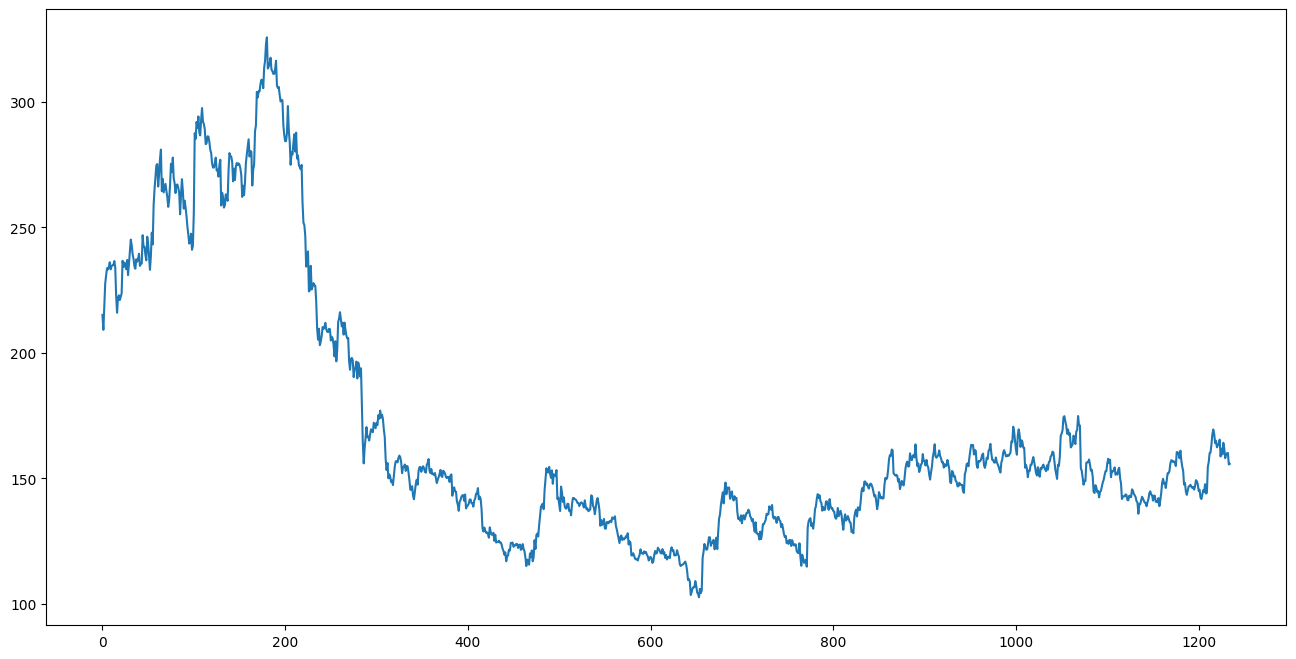

In [4]:
plt.figure(figsize=(16,8))
plt.plot(data["Close"], label = "closing price")

In [5]:
data["Open - Close"] = data["Open"] - data["Close"]
data["High - Low"] = data["High"] - data["Low"]
data = data.dropna()

input features to predict whether customer should buy or sell the stock

In [6]:
x = data[["Open - Close", "High - Low"]]
x.head()

,Open - Close,High - Low
0,-7.15,15.40
1,7.80,12.70
2,5.30,11.65
3,2.40,11.75
4,3.65,13.55


classification problem : buy(+1) or sell(-1) the stock

In [7]:
y = np.where(data["Close"].shift(-1)>data["Close"],1,-1)

In [8]:
y

array([-1,  1,  1, ..., -1,  1, -1], shape=(1235,))

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 40)

implementation of KNN classifier

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [19]:
#using gridsearch to find the best parameter
params = {"n_neighbors": list(range(2, 16))}

knn = neighbors.KNeighborsClassifier()
model = GridSearchCV(knn, params, cv=5)

#fit the model
model.fit(x_train, y_train)

# predictions
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

#accuracy score
accuracy_train = accuracy_score(y_train, train_pred)
accuracy_test = accuracy_score(y_test, test_pred)

print("train data accuracy: %.2f" %accuracy_train)
print("test data accuracy: %.2f" %accuracy_test)

# best parameter
print("Best n_neighbors:", model.best_params_)

train data accuracy: 0.88
test data accuracy: 0.89
Best n_neighbors: {'n_neighbors': 13}


In [20]:
predictions_classification = test_pred

In [21]:
actual_prediction_data = pd.DataFrame({"actual class": y_test, "predicted class": predictions_classification})

In [22]:
actual_prediction_data.head(10)

,actual class,predicted class
0,-1,-1
1,1,1
2,-1,-1
3,-1,-1
4,-1,-1
5,-1,-1
6,-1,-1
7,-1,-1
8,-1,-1
9,1,1


In [18]:
y = data["Close"]
y

0       215.15
1       209.20
2       218.20
3       227.60
4       230.90
         ...  
1230    159.45
1231    160.05
1232    160.15
1233    155.55
1234    155.80
Name: Close, Length: 1235, dtype: float64